In [9]:
from pandas import read_csv, concat
import seaborn as sns

import matplotlib.pyplot as plt


In [2]:
train_df = read_csv("../data/emotions_train.csv")
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21459 entries, 0 to 21458
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Text     21459 non-null  object
 1   Emotion  21459 non-null  object
dtypes: object(2)
memory usage: 335.4+ KB


In [3]:
test_df = read_csv("../data/emotions_test.csv")
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tweet_id   40000 non-null  int64 
 1   sentiment  40000 non-null  object
 2   author     40000 non-null  object
 3   content    40000 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.2+ MB


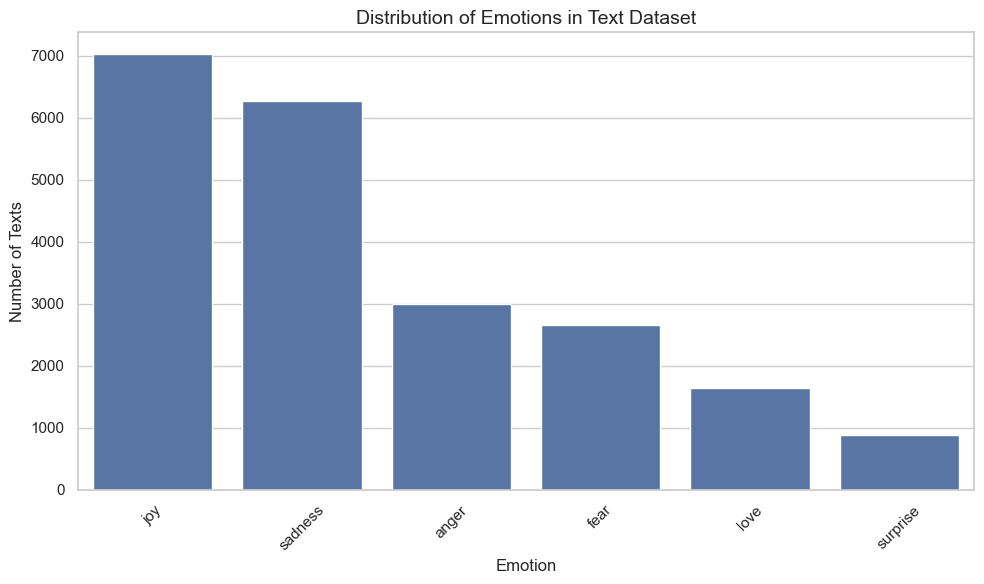

In [4]:
plt.figure(figsize=(10, 6))                                        
sns.set_theme(style="whitegrid")                                   
                                                                   
sns.countplot(                                                    
    data=train_df,                                                      
    x="Emotion",                                                  
    order=train_df["Emotion"].value_counts().index                      
)                                                                 
                                                                  
plt.title("Distribution of Emotions in Text Dataset", fontsize=14)
plt.xlabel("Emotion")                                             
plt.ylabel("Number of Texts")                                     
plt.xticks(rotation=45)                                           
plt.tight_layout()                                                
plt.show()   

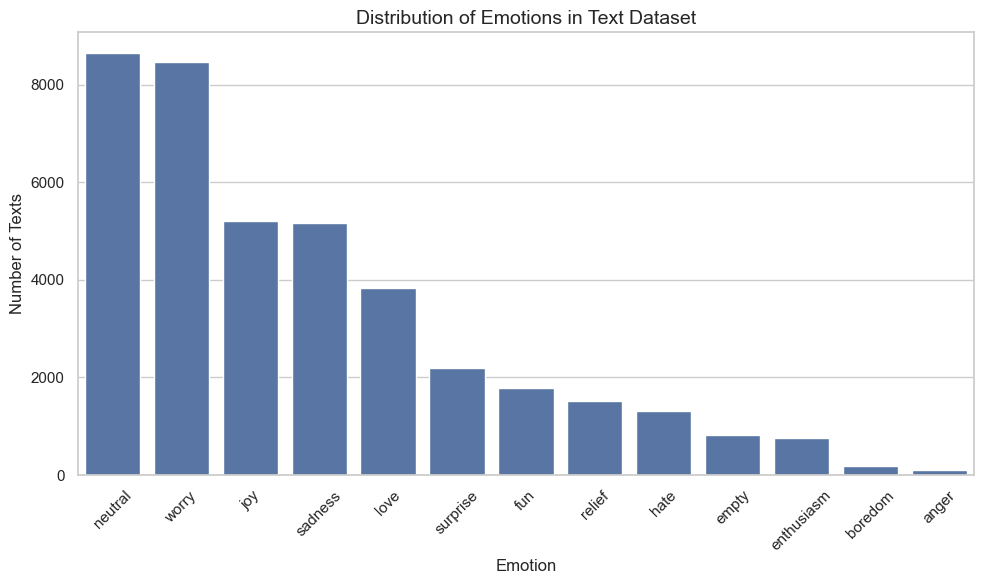

In [6]:
plt.figure(figsize=(10, 6))                                        
sns.set_theme(style="whitegrid")                                   
                                                                   
sns.countplot(                                                    
    data=test_df,                                                      
    x="sentiment",                                                  
    order=test_df["sentiment"].value_counts().index                      
)                                                                 
                                                                  
plt.title("Distribution of Emotions in Text Dataset", fontsize=14)
plt.xlabel("Emotion")                                             
plt.ylabel("Number of Texts")                                     
plt.xticks(rotation=45)                                           
plt.tight_layout()                                                
plt.show()   

In [7]:
test_df.drop(columns=['author', 'tweet_id'], inplace=True)

In [8]:
def map_sentiment_test_to_train(label: str) -> str:
    if label in ['joy', 'fun', 'enthusiasm', 'relief']:
        return 'joy'
    elif label in ['anger', 'hate']:
        return 'anger'
    elif label in ['worry']:
        return 'fear'
    elif label in ['sadness', 'empty', 'boredom']:
        return 'sadness'
    return label 

test_df['sentiment'] = test_df['sentiment'].apply(map_sentiment_test_to_train)
test_df = test_df[test_df['sentiment'] != 'neutral']
test_df['sentiment'].unique()

array(['sadness', 'joy', 'fear', 'surprise', 'love', 'anger'],
      dtype=object)

In [10]:
test_df['text'] = test_df['content']
test_df.drop(columns=['content'], inplace=True)
test_df['emotion'] = test_df['sentiment']
test_df.drop(columns=['sentiment'], inplace=True)
train_df['text'] = train_df['Text']
train_df.drop(columns=['Text'], inplace=True)
train_df['emotion'] = train_df['Emotion']
train_df.drop(columns=['Emotion'], inplace=True)

dataframe = concat([train_df, test_df], ignore_index=True)

C:\Users\cleme\AppData\Local\Temp\ipykernel_16564\1109965811.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['text'] = test_df['content']
C:\Users\cleme\AppData\Local\Temp\ipykernel_16564\1109965811.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.drop(columns=['content'], inplace=True)
C:\Users\cleme\AppData\Local\Temp\ipykernel_16564\1109965811.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http

In [11]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52821 entries, 0 to 52820
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text     52821 non-null  object
 1   emotion  52821 non-null  object
dtypes: object(2)
memory usage: 825.5+ KB


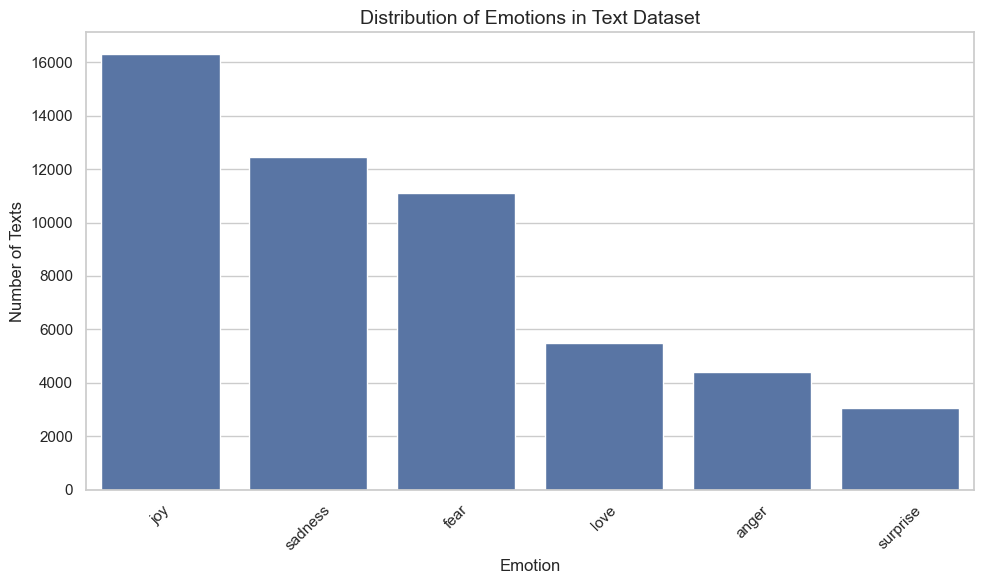

In [12]:
plt.figure(figsize=(10, 6))                                        
sns.set_theme(style="whitegrid")                                   
                                                                   
sns.countplot(                                                    
    data=dataframe,                                                      
    x="emotion",                                                  
    order=dataframe["emotion"].value_counts().index                      
)                                                                 
                                                                  
plt.title("Distribution of Emotions in Text Dataset", fontsize=14)
plt.xlabel("Emotion")                                             
plt.ylabel("Number of Texts")                                     
plt.xticks(rotation=45)                                           
plt.tight_layout()                                                
plt.show()   

In [13]:
dataframe.to_csv('../data/emotions.csv')